In [2]:
import pandas as pd

In [3]:
cpi = pd.read_excel(r"data/CPI_By_Dec.xlsx")
cpi

,cpi_total,food,non_food,paid_services
0,100.7,101.0,100.3,100.6
1,101.5,102.2,100.8,101.2
2,105.2,108.2,103.6,102.6
3,107.3,111.6,104.9,103.6
4,108.8,113.5,106.3,104.5
5,110.5,115.7,108.4,105.3
6,111.7,116.9,110.0,106.2
7,113.3,118.0,111.9,107.9
8,115.4,119.5,114.0,110.8
9,117.2,121.2,116.0,112.6


In [4]:
import pandas as pd
import numpy as np


years = np.repeat([2022, 2023, 2024, 2025], 12)
months = list(range(1, 13)) * 4

cpi["year"] = years
cpi["month"] = months


In [5]:
cpi["date"] = pd.to_datetime(
    cpi["year"].astype(str) + "-" + cpi["month"].astype(str) + "-01"
)

In [6]:
cpi

,cpi_total,food,non_food,paid_services,year,month,date
0,100.7,101.0,100.3,100.6,2022,1,2022-01-01
1,101.5,102.2,100.8,101.2,2022,2,2022-02-01
2,105.2,108.2,103.6,102.6,2022,3,2022-03-01
3,107.3,111.6,104.9,103.6,2022,4,2022-04-01
4,108.8,113.5,106.3,104.5,2022,5,2022-05-01
5,110.5,115.7,108.4,105.3,2022,6,2022-06-01
6,111.7,116.9,110.0,106.2,2022,7,2022-07-01
7,113.3,118.0,111.9,107.9,2022,8,2022-08-01
8,115.4,119.5,114.0,110.8,2022,9,2022-09-01
9,117.2,121.2,116.0,112.6,2022,10,2022-10-01


In [7]:
cpi["cpi_lag_monthly"]=cpi["cpi_total"].shift(1)
cpi["cpi_lag_quartal"]=cpi["cpi_total"].shift(3)
cpi["cpi_lag_by_year"]=cpi["cpi_total"].shift(12)

In [8]:
cpi[["food","non_food","paid_services"]].describe()

,food,non_food,paid_services
count,48.00000,48.000000,48.000000
mean,107.71875,106.087500,107.087500
std,6.16937,4.478489,4.055762
min,101.00000,100.300000,100.600000
25%,102.90000,102.800000,103.600000
50%,105.85000,105.200000,107.100000
75%,110.17500,108.325000,110.850000
max,125.30000,119.400000,114.100000


In [9]:
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

cpi["month_names"] = cpi["month"].map(month_map)

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

cpi["month_names"] = pd.Categorical(
    cpi["month_names"],
    categories=month_order,
    ordered=True
)


In [10]:
cpi

,cpi_total,food,non_food,paid_services,year,month,date,cpi_lag_monthly,cpi_lag_quartal,cpi_lag_by_year,month_names
0,100.7,101.0,100.3,100.6,2022,1,2022-01-01,NaN,NaN,NaN,Jan
1,101.5,102.2,100.8,101.2,2022,2,2022-02-01,100.7,NaN,NaN,Feb
2,105.2,108.2,103.6,102.6,2022,3,2022-03-01,101.5,NaN,NaN,Mar
3,107.3,111.6,104.9,103.6,2022,4,2022-04-01,105.2,100.7,NaN,Apr
4,108.8,113.5,106.3,104.5,2022,5,2022-05-01,107.3,101.5,NaN,May
5,110.5,115.7,108.4,105.3,2022,6,2022-06-01,108.8,105.2,NaN,Jun
6,111.7,116.9,110.0,106.2,2022,7,2022-07-01,110.5,107.3,NaN,Jul
7,113.3,118.0,111.9,107.9,2022,8,2022-08-01,111.7,108.8,NaN,Aug
8,115.4,119.5,114.0,110.8,2022,9,2022-09-01,113.3,110.5,NaN,Sep
9,117.2,121.2,116.0,112.6,2022,10,2022-10-01,115.4,111.7,NaN,Oct


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 0, 'Year')

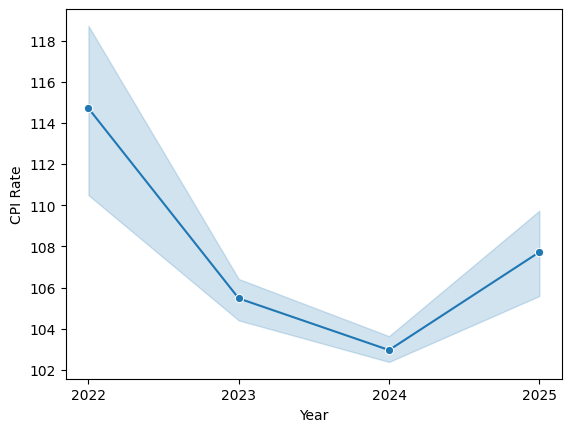

In [12]:
sns.lineplot(data=cpi,x="year",y="food",marker="o")
plt.xticks([2022, 2023, 2024, 2025])
plt.ylabel("CPI Rate")
plt.xlabel("Year")

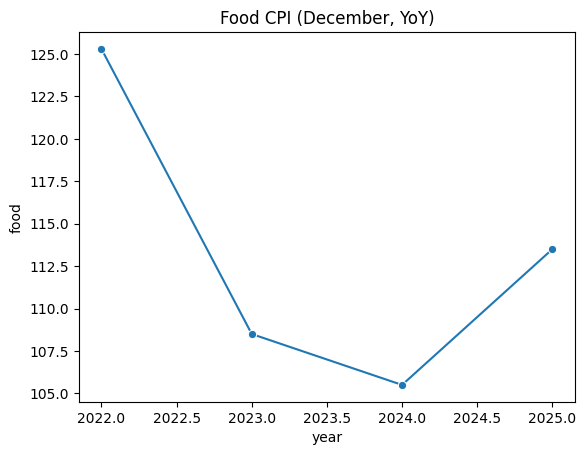

In [13]:
december = cpi[cpi["month"] == 12]

sns.lineplot(data=december, x="year", y="food", marker="o")
plt.title("Food CPI (December, YoY)")
plt.show()


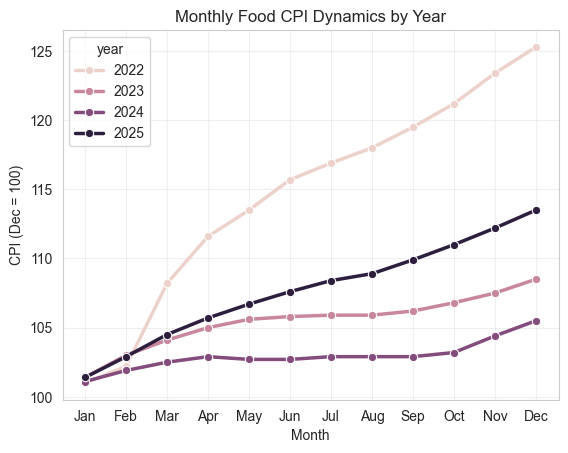

In [14]:
sns.set_style("whitegrid")
sns.set_palette("colorblind")
sns.lineplot(
    data=cpi,
    x="month_names",
    y="food",
    hue="year",
    linewidth=2.5,
    marker="o"
)

plt.title("Monthly Food CPI Dynamics by Year")
plt.xlabel("Month")
plt.ylabel("CPI (Dec = 100)")
plt.grid(True, alpha=0.3)
plt.show()


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Thesis / LaTeX-like styling (no actual LaTeX needed) ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

sns.set_style("whitegrid")
sns.set_palette("colorblind")

plt.figure(figsize=(6.5, 4))  # good for LaTeX documents

sns.lineplot(
    data=cpi,
    x="month_names",
    y="food",
    hue="year",
    linewidth=2.5,
    marker="o"
)

plt.title("Monthly Food CPI Dynamics by Year")
plt.xlabel("Month")
plt.ylabel("CPI (Dec = 100)")
plt.grid(True, alpha=0.3)

plt.tight_layout()

# ✅ Save as LaTeX-ready PNG
plt.savefig("plots/week_1/food_cpi_by_year.png", dpi=300, bbox_inches="tight")

plt.show()


C:\Users\Seidahmet\AppData\Local\Temp\ipykernel_2484\1233651007.py:37: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


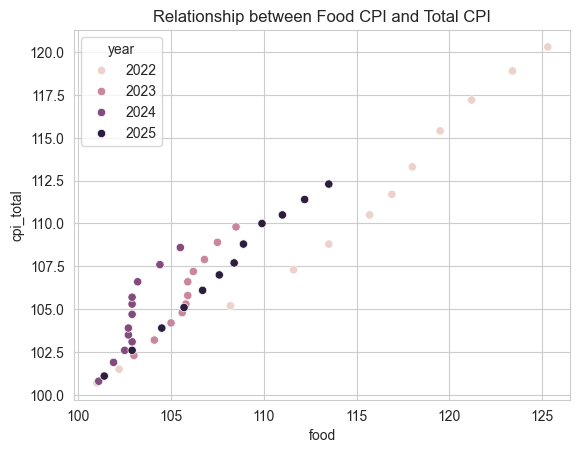

In [15]:
sns.scatterplot(data=cpi, x="food", y="cpi_total", hue="year")
plt.title("Relationship between Food CPI and Total CPI")
plt.show()


In [16]:
cpi[["food","cpi_total"]].corr()


,food,cpi_total
food,1.000000,0.948203
cpi_total,0.948203,1.000000


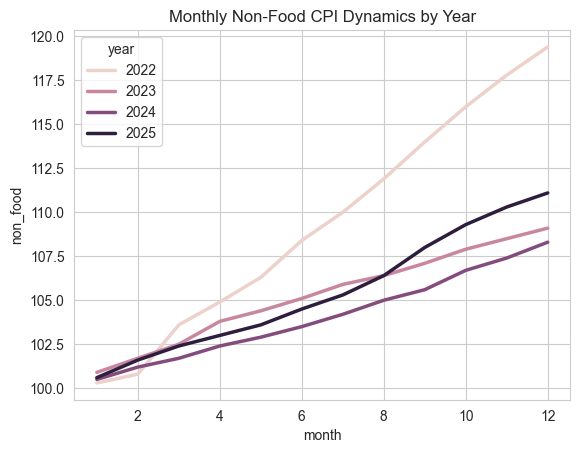

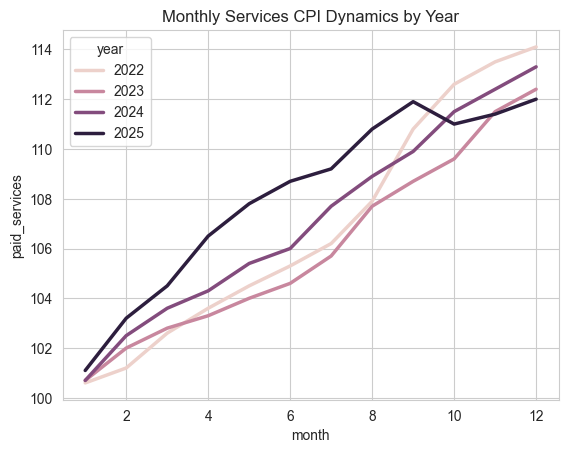

In [17]:
sns.lineplot(data=cpi, x="month", y="non_food", hue="year", linewidth=2.5)
plt.title("Monthly Non-Food CPI Dynamics by Year")
plt.show()

sns.lineplot(data=cpi, x="month", y="paid_services", hue="year", linewidth=2.5)
plt.title("Monthly Services CPI Dynamics by Year")
plt.show()


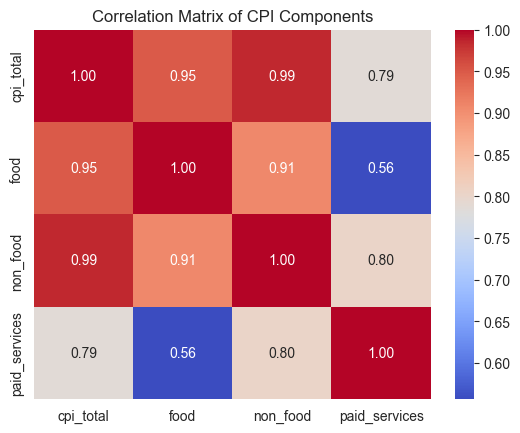

In [18]:
sns.heatmap(
    cpi[["cpi_total","food","non_food","paid_services"]].corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Matrix of CPI Components")
plt.savefig('plots/week_1/corr_cpi.png')
plt.show()


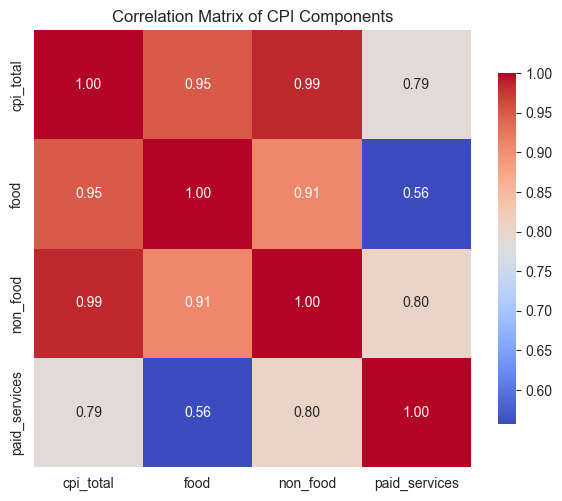

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cpi[["cpi_total","food","non_food","paid_services"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix of CPI Components", fontsize=12)
plt.tight_layout()

plt.savefig(
    "plots/week_1/corr_cpi.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


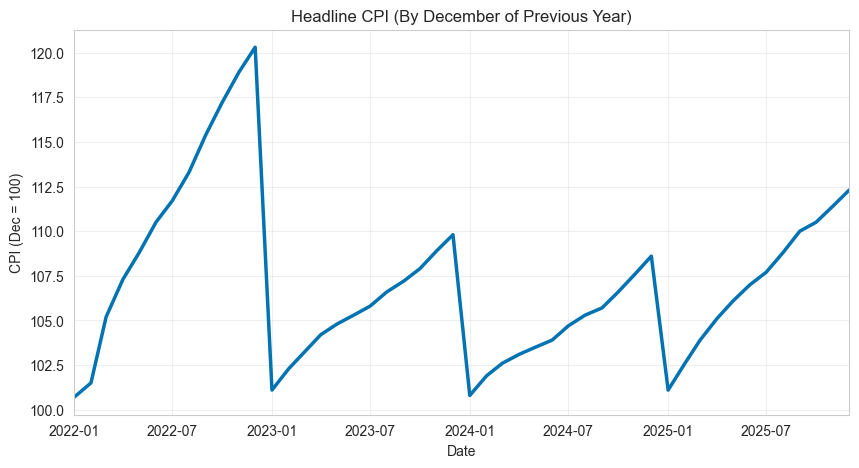

In [20]:
plt.figure(figsize=(10,5))
sns.lineplot(data=cpi, x="date", y="cpi_total", linewidth=2.5)
plt.xlim(cpi["date"].min(), cpi["date"].max())
plt.title("Headline CPI (By December of Previous Year)")
plt.xlabel("Date")
plt.ylabel("CPI (Dec = 100)")
plt.grid(alpha=0.3)
plt.savefig('plots/week_1/headline_cpi.png',dpi=300,bbox_inches='tight')
plt.show()


In [21]:
#Average annual food inflation (relative to previous December), %
cpi.loc[cpi["month"]==12].groupby("year")["food"].last()-100


year
2022    25.3
2023     8.5
2024     5.5
2025    13.5
Name: food, dtype: float64

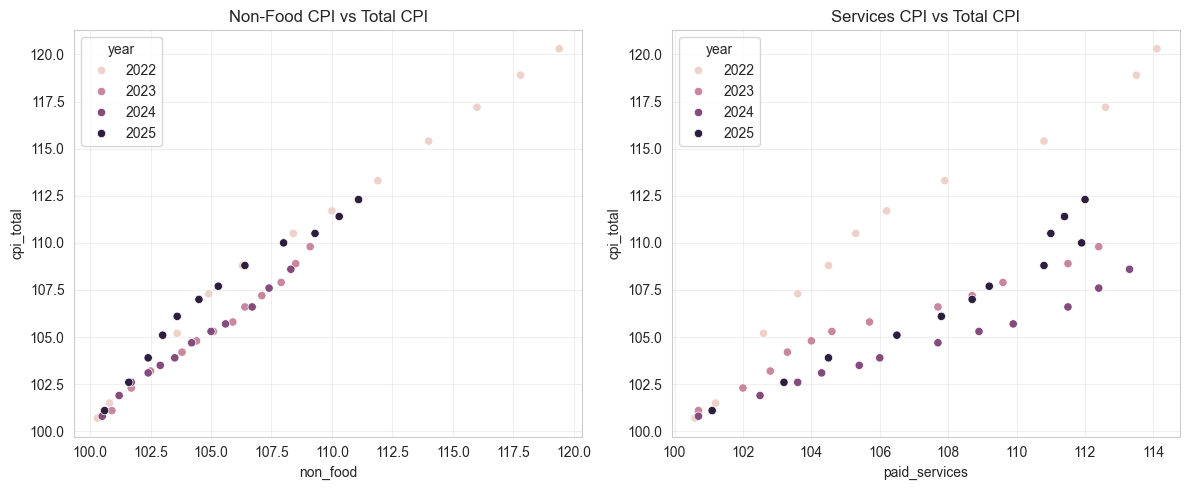

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(
    data=cpi, x="non_food", y="cpi_total", hue="year", ax=axes[0]
)
axes[0].set_title("Non-Food CPI vs Total CPI")

sns.scatterplot(
    data=cpi, x="paid_services", y="cpi_total", hue="year", ax=axes[1]
)
axes[1].set_title("Services CPI vs Total CPI")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [28]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=cpi,
    x="month",
    y="non_food",
    hue="year",
    linewidth=2.5,
    marker="o"
)
plt.title("Monthly Non-Food CPI Dynamics by Year")
plt.xlabel("Month")
plt.ylabel("CPI (Dec = 100)")
plt.grid(alpha=0.3)
plt.savefig('plots/week_1/nf_cpi.png',dpi=300,bbox_inches='tight')
plt.show()


plt.figure(figsize=(10,6))
sns.lineplot(
    data=cpi,
    x="month",
    y="paid_services",
    hue="year",
    linewidth=2.5,
    marker="o"
)
plt.title("Monthly Services CPI Dynamics by Year")
plt.xlabel("Month")
plt.ylabel("CPI (Dec = 100)")
plt.grid(alpha=0.3)
plt.savefig('plots/week_1/cpi_dyn.png',dpi=300,bbox_inches='tight')
plt.show()


C:\Users\Seidahmet\AppData\Local\Temp\ipykernel_2484\1204172813.py:15: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\Seidahmet\AppData\Local\Temp\ipykernel_2484\1204172813.py:32: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


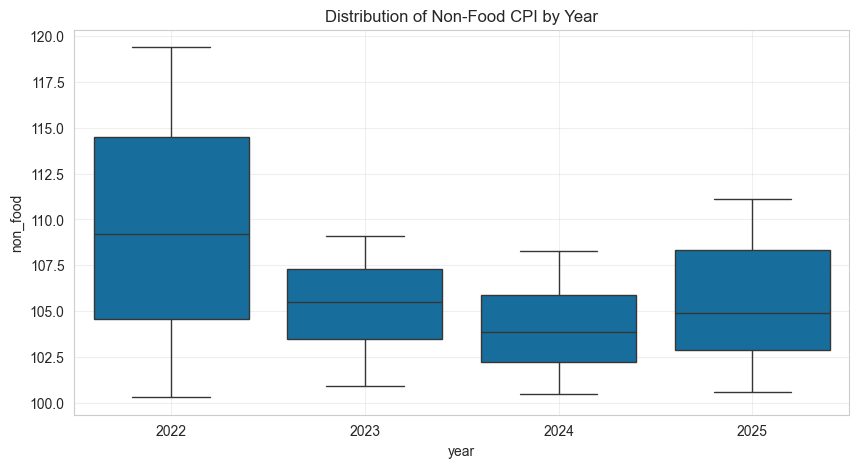

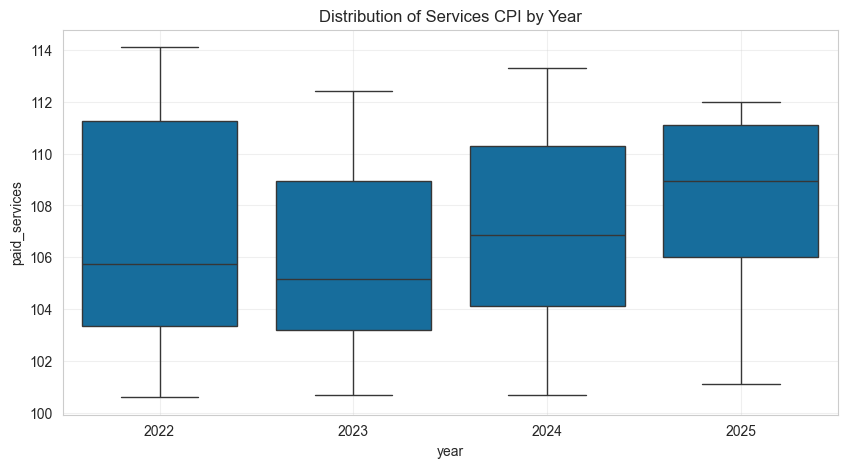

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=cpi,
    x="year",
    y="non_food"
)
plt.title("Distribution of Non-Food CPI by Year")
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(10,5))
sns.boxplot(
    data=cpi,
    x="year",
    y="paid_services"
)
plt.title("Distribution of Services CPI by Year")
plt.grid(alpha=0.3)
plt.show()

In [25]:
import matplotlib as mpl
mpl.use("pgf")

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",   # or "xelatex" / "lualatex"
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
})

import matplotlib.pyplot as plt

yearly_mean = cpi.groupby("year")[["food","non_food","paid_services"]].mean().reset_index()

plt.figure(figsize=(6,4))

plt.plot(yearly_mean["year"], yearly_mean["food"], marker="o", label="Food")
plt.plot(yearly_mean["year"], yearly_mean["non_food"], marker="o", label="Non-Food")
plt.plot(yearly_mean["year"], yearly_mean["paid_services"], marker="o", label="Services")

plt.title("Average CPI Components by Year")
plt.xlabel("Year")
plt.ylabel("CPI (Dec = 100)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
# plt.savefig("plots/week_1/cpi_plot.pgf")   # ✅ LaTeX-ready output
# plt.savefig("plots/week_1/cpi_plot.pdf")
plt.savefig("plots/week_1/cpi_plot.png",dpi=300,bbox_inches="tight")   # optional: a PDF copy
# optional: a PDF copy
plt.show()


C:\Users\Seidahmet\AppData\Local\Temp\ipykernel_2484\1761635031.py:32: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


In [26]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score


cpi = cpi.dropna().reset_index(drop=True)
X=cpi[["food","non_food","paid_services","month","cpi_lag_monthly","cpi_lag_quartal","cpi_lag_by_year"]]
Y=cpi["cpi_total"]

train_size = int(len(cpi) * 0.8)

X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]

y_train = Y.iloc[:train_size]
y_test  = Y.iloc[train_size:]
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
y_naive = X_test["cpi_lag_monthly"]



mae_naive = mean_absolute_error(y_test, y_naive)
rmse_naive = mean_squared_error(y_test, y_naive)
r2_naive = r2_score(y_test,y_naive)
print(f"MAE:{mae:.2f}")
print(f"RMSE:{rmse:.2f}")
print(f"R2:{r2:.2f}")
print(f"MAE_Naive:{mae_naive:.2f}")
print(f"RMSE_Naive:{rmse_naive:.2f}")
print(f"R2_naive:{r2_naive}")

MAE:0.05
RMSE:0.00
R2:1.00
MAE_Naive:0.90
RMSE_Naive:0.85
R2_naive:0.7972350230414748
